# 📊 Leitura e Plots de Dados Já Tratados (Silver)

Notebook focado **somente na pasta chulha**:
- usa os módulos `dataprep.py` e `plot_utils.py`;
- lê apenas dados já tratados de `chulha/data/silver`;
- plota exemplos rápidos para inspeção.

In [7]:
from pathlib import Path
import sys
import io
import contextlib
import pandas as pd
import matplotlib.pyplot as plt

# Descobrir base da pasta chulha
cwd = Path.cwd().resolve()
if cwd.name == 'chulha':
    BASE_CHULHA = cwd
elif (cwd / 'chulha').exists():
    BASE_CHULHA = (cwd / 'chulha').resolve()
else:
    raise FileNotFoundError('Execute em chulha/ ou no diretório pai que contém chulha/.')

if str(BASE_CHULHA) not in sys.path:
    sys.path.insert(0, str(BASE_CHULHA))

from dataprep import DataLoader
from plot_utils import PlotterGFET

print(f'✅ BASE_CHULHA: {BASE_CHULHA}')

✅ BASE_CHULHA: /home/v/Documents/contas/chulha


In [8]:
# Caminho único de dados tratados dentro de chulha
base_silver = BASE_CHULHA / 'data' / 'silver'
if not base_silver.exists():
    raise FileNotFoundError(f'Pasta não encontrada: {base_silver}')

print(f'✅ Pasta silver: {base_silver}')

✅ Pasta silver: /home/v/Documents/contas/chulha/data/silver


In [9]:
# Selecionar experimento e subpasta automaticamente
experimentos = sorted([p for p in base_silver.iterdir() if p.is_dir()])
if not experimentos:
    raise FileNotFoundError(f'Nenhum experimento encontrado em {base_silver}')

experimento = experimentos[0]
subpastas = sorted([p for p in experimento.iterdir() if p.is_dir()])
pasta_dados = subpastas[0] if subpastas else experimento

print(f'📅 Experimento selecionado: {experimento.name}')
print(f'📂 Pasta de dados: {pasta_dados}')

📅 Experimento selecionado: 19abr
📂 Pasta de dados: /home/v/Documents/contas/chulha/data/silver/19abr/19abr_curves


In [10]:
# Carregar dados e mapear tudo que existe (chips, etapas e devices)
loader = DataLoader(str(pasta_dados))
chips = loader.listar_chips_disponiveis()
if not chips:
    raise FileNotFoundError(f'Nenhum arquivo *_ajustado.csv encontrado em {pasta_dados}')

resumo = []
dados_por_chip = {}
for ch in chips:
    # Evitar poluição de print do carregar_chip durante o mapeamento
    with contextlib.redirect_stdout(io.StringIO()):
        dados_chip = loader.carregar_chip(ch)
    dados_por_chip[ch] = dados_chip

    etapas_chip = sorted(list(dados_chip.keys()))
    devices_chip = loader.obter_colunas_disponiveis(dados_chip)
    resumo.append({
        'chip': ch,
        'n_etapas': len(etapas_chip),
        'n_devices': len(devices_chip),
        'etapas': ', '.join(etapas_chip) if etapas_chip else '(sem etapas)'
    })

df_resumo = pd.DataFrame(resumo).sort_values(['n_etapas', 'n_devices'], ascending=False).reset_index(drop=True)
print('📋 Mapeamento disponível na pasta selecionada:')
display(df_resumo)

etapas_preferidas = ['bare', 'etoh', 'ddt', 'pbse', 'apt', 'eta']
chip = None
for ch in chips:
    etapas_chip = set(dados_por_chip[ch].keys())
    if any(e in etapas_chip for e in etapas_preferidas):
        chip = ch
        break

if chip is None:
    chip = chips[0]

dados = dados_por_chip[chip]
devices = loader.obter_colunas_disponiveis(dados)
etapas_plot = [e for e in etapas_preferidas if e in dados]
if not etapas_plot:
    etapas_plot = list(dados.keys())

print(f'\n🔬 Chip selecionado para os exemplos: {chip}')
print(f'📈 Etapas que serão usadas no plot: {etapas_plot}')
print(f'🎯 Devices disponíveis: {len(devices)}')

📋 Mapeamento disponível na pasta selecionada:


,chip,n_etapas,n_devices,etapas
0,C3,13,20,"apt, b1, b2, b3, c100ng, c25ng, c50ng, c75ng, ..."
1,C4,9,20,"apt, b1, b2, c25ng, c50ng, c75ng, eta, etoh, pbse"
2,C1,4,20,"c25ng, menos12, menos15, menos18"
3,C2,4,20,"b3, ddt, eta, pbse"
4,C5,1,20,bare



🔬 Chip selecionado para os exemplos: C2
📈 Etapas que serão usadas no plot: ['ddt', 'pbse', 'eta']
🎯 Devices disponíveis: 20


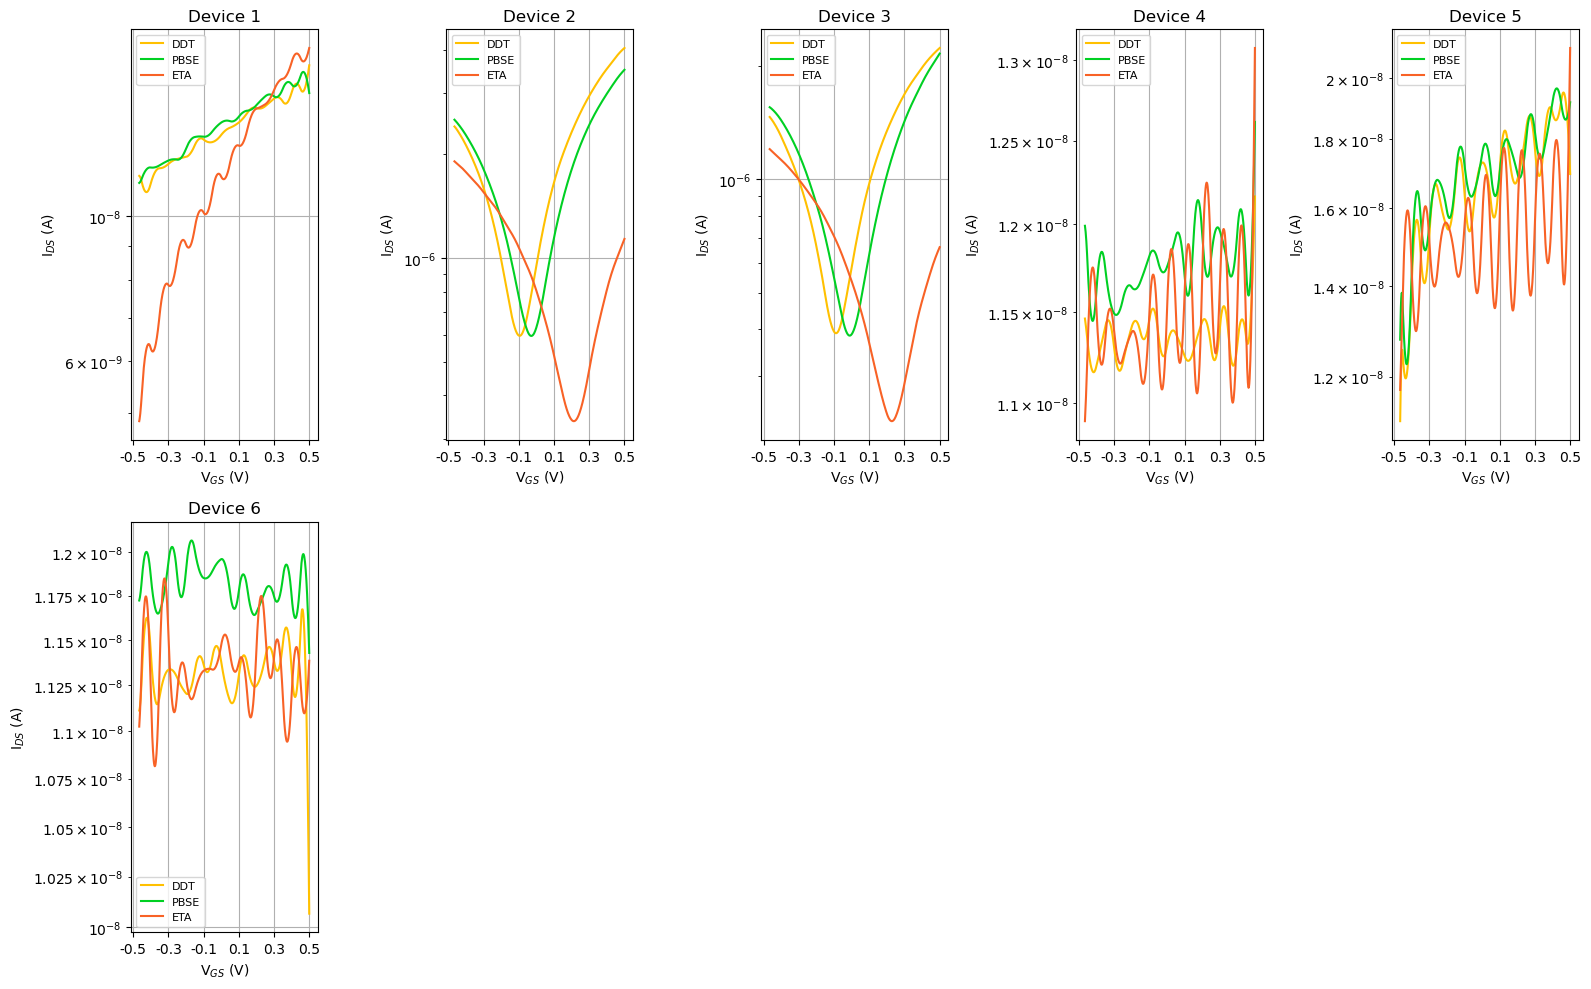

In [11]:
# Exemplo 1: Grid de transferência (com fallback automático de etapas)
plotter = PlotterGFET(chip_name=chip)

if not etapas_plot:
    raise ValueError('Nenhuma etapa disponível para plotar no chip selecionado.')

devices_plot = devices[:min(6, len(devices))]
if not devices_plot:
    raise ValueError('Nenhum device disponível para plotar no chip selecionado.')

dados_subset = {}
for etapa in etapas_plot:
    df = dados[etapa]
    cols = ['V_G'] + [d for d in devices_plot if d in df.columns]
    if len(cols) > 1:
        dados_subset[etapa] = df[cols]

if not dados_subset:
    raise ValueError('Não foi possível montar dados_subset para o grid.')

fig = plotter.plot_curvas_transferencia_grid(
    dados=dados_subset,
    etapas=list(dados_subset.keys()),
    figsize=(16, 10),
    devices=devices_plot
)
plt.show()

In [ ]:
# Exemplo 2: Device individual (absoluta + normalizada)
if not devices:
    raise ValueError('Nenhum device disponível para plot individual.')

device_exemplo = devices[0]

fig = plotter.plot_device_individual(
    dados=dados,
    device=device_exemplo,
    etapas=etapas_plot,
    normalizado=False,
    figsize=(10, 6)
)
plt.show()

fig = plotter.plot_device_individual(
    dados=dados,
    device=device_exemplo,
    etapas=etapas_plot,
    normalizado=True,
    figsize=(10, 6)
)
plt.show()

ValueError: Device 1 não encontrado em nenhuma etapa

In [ ]:
# Exemplo 3: Curvas de concentração (se houver no chip)
concentracoes_disponiveis = [
    c for c in ['menos18', 'menos17', 'menos16', 'menos15', 'menos14', 'menos13',
                'menos12', 'menos11', 'menos10', 'menos9', 'menos8',
                'c10ng', 'c25ng', 'c50ng', 'c75ng', 'c100ng']
    if c in dados
]

if concentracoes_disponiveis:
    fig = plotter.plot_concentracoes(
        dados=dados,
        device=device_exemplo,
        concentracoes=concentracoes_disponiveis[:5],
        incluir_branca=True,
        normalizado=False,
        figsize=(11, 7)
    )
    plt.show()
else:
    print('ℹ️ Não há etapas de concentração disponíveis para este chip.')

## Ajustes rápidos

- Para reproduzir sempre o mesmo caso, fixe manualmente `experimento`, `pasta_dados` e `chip`.
- Para salvar figuras: `plotter.salvar_figura(fig, BASE_CHULHA / 'resultados' / 'nome.png')`.